## 1. Data Loading & Preprocessing (MedMNIST v2)

In this step, we prepare the dataset for the Diffusion Model.

**Dataset:**
We are using **PneumoniaMNIST** from the [MedMNIST v2 collection](https://medmnist.com/).
* **Source:** 5,856 Chest X-Rays.
* **Resolution:** We configure the loader to fetch **128x128** images (High-Res) instead of the default 28x28.
* **Classes:** 0 = Normal (Healthy), 1 = Pneumonia (Sick).

**Preprocessing Pipeline:**
1.  **Download:** Automatically fetches the `.npz` file if not present.
2.  **Normalization:** We scale pixel values from `[0, 1]` to `[-1, 1]`. This is standard for Diffusion Models (DDPM) to match the range of the Gaussian noise.
3.  **Modular Loading:** The code is wrapped in a `load_data()` function, allowing us to easily switch resolutions (e.g., `64x64` vs `128x128`) later without restarting the kernel.

## Setup required packages and libraries

In [12]:
import sys
import os
import subprocess

import torch
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset

import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, roc_auc_score

## Loading the Data

Using Apple (MPS) Acceleration
Preparing Data (Size: 128x128)
Filtering training data to ONLY include healthy lungs (Label 0)...
Sanity Check - Unique labels in training batch: tensor([0])
Data Successfully Loaded! 1214 healthy training images, 624 testing images.

 Displaying Sample Images...


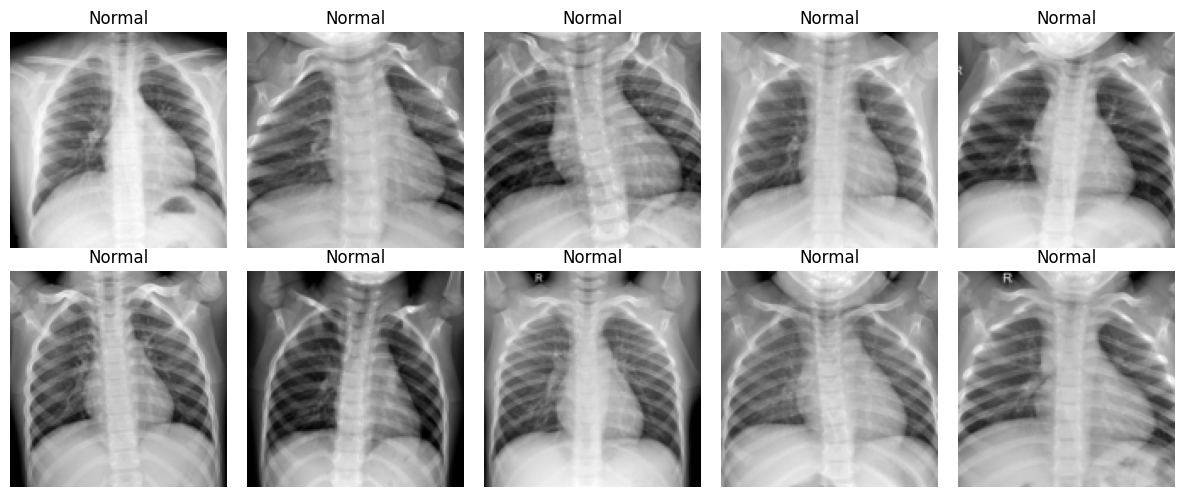

In [3]:
# Check whether the medmnist is installed 
try:
    import medmnist
    from medmnist import INFO
except ImportError:
    print("Installing medmnist...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "medmnist"])
    import medmnist
    from medmnist import INFO

# Load data from medmnist
def load_data(img_size=64, batch_size=128):
    """
    Downloads and prepares the PneumoniaMNIST data.
    Returns: train_loader, test_dataset, device
    """
    # Setup device for torch training. 
    # If the computer has a GPU setting up to use it else use CPU. 
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print(f"Using Apple (MPS) Acceleration")
    else:
        device = torch.device("cpu")
        print("Using CPU")

    print(f"Preparing Data (Size: {img_size}x{img_size})")

    # Define image transformation
    # Normalize to [-1, 1] for Diffusion Model which expect input centered at 0
    data_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[.5], std=[.5])
    ])

    # Download and initialize the dataset
    train_dataset = medmnist.PneumoniaMNIST(
        split='train', 
        transform=data_transform, 
        download=True, 
        size=img_size
    )
    
    test_dataset = medmnist.PneumoniaMNIST(
        split='test', 
        transform=data_transform, 
        download=True, 
        size=img_size
    )

    print("Filtering training data to ONLY include healthy lungs (Label 0)...")
    
    # Find the index of every image that has a label of 0 (Normal)
    healthy_indices = np.where(train_dataset.labels.squeeze() == 0)[0].tolist()
    
    # Create a new dataset using ONLY those healthy indices
    healthy_train_dataset = Subset(train_dataset, healthy_indices)

    # Create data loader for the train using the FILTERED dataset
    train_loader = DataLoader(
        dataset=healthy_train_dataset, # <--- Only healthy lungs for training
        batch_size=batch_size, 
        shuffle=True
    )
    
    # Verify that the training loader only contains label 0
    imgs, lbls = next(iter(train_loader))
    print("Sanity Check - Unique labels in training batch:", torch.unique(lbls))
    
    # Create data loader for the test (shuffle=False keeps labels aligned)
    test_loader = DataLoader(
        dataset=test_dataset, 
        batch_size=batch_size, 
        shuffle=False
    )

    print(f"Data Successfully Loaded! {len(healthy_train_dataset)} healthy training images, {len(test_dataset)} testing images.")
    return train_loader, test_loader, test_dataset, device

# -- Execution and verification --
IMG_SIZE = 128
BATCH_SIZE = 64

train_loader, test_loader, test_dataset, device = load_data(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

# -- Visualization --
print("\n Displaying Sample Images...")

# Take one batch
images, labels = next(iter(train_loader))

# Remove the normalization for display purpose: (-1, 1) -> (0, 1)
images_display = images / 2 + 0.5

plt.figure(figsize=(12, 5))
for i in range(10):  # Show 10 images from the batch
    plt.subplot(2, 5, i+1)
    img = images_display[i].squeeze().numpy()
    lbl = labels[i].item()
    
    plt.imshow(img, cmap='gray')
    plt.title("Pneumonia" if lbl == 1 else "Normal")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 2. The Diffusion Model (U-Net Architecture)

Now we define the neural network. We use a **U-Net** architecture, which is standard for Diffusion Models.

**How it works:**
The U-Net takes two inputs:
1.  `x`: The noisy image (e.g., an X-ray with added static).
2.  `t`: The current "time" step (how much noise was added).

**The Goal:**
The network outputs a prediction of the **noise** that was added to the image. By subtracting this predicted noise, we can "clean" the image step-by-step.

$$\epsilon_{\theta}(x_t, t) \approx \epsilon$$

We also define a custom `PyTorch Dataset` class to feed our `.npz` data into the model efficiently.

In [4]:
# --- Define the U-Net Architecture ---
# Time embedding (Time --> Embedding vector)
class SinusoidalPositionEmbeddings(nn.Module):
    # Initialize neural network module with the size of embedding vector 'dim'
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2 # Build half embedding with Sin and other half with Cos
        embeddings = np.log(10000) / (half_dim - 1) # Setting the spacing of frequencies
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings) # Getting vector of decreasing frequencies
        embeddings = time[:, None] * embeddings[None, :] # Generating a vector for each sample t.ω 
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1) # Apply sin and cos for smooth periodic features
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim=64):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1) # 2D Convolution layer, kernal is 3x3
        self.norm = nn.GroupNorm(8, out_ch) # GroupNorm stabilizes training
        self.act = nn.SiLU() # SiLU (Swish) activation function better for diffusion
        
        # Project time embeddings to match channel dimensions (B, time_emb_dim) --> (B, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t):
        h = self.conv(x)
        # Add time embedding (broadcast to image spatial dims)
        time_emb = self.act(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2] # Reshape time embedding to match spatial dimensions
        h = h + time_emb # Add time conditioning to every spatial location
        return self.act(self.norm(h))

class BetterUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Time Embedding Block
        # Timestep turning into 64 dimensions vector
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(32),
            nn.Linear(32, 64),
            nn.SiLU(),
            nn.Linear(64, 64)
        )

        # Encoder (Downsampling)
        self.conv0 = nn.Conv2d(1, 32, 3, padding=1) # Input channel is 1 (grayscale), output channel is 32, kernel size is 3x3, padding is 1
        self.down1 = Block(32, 64, 64)
        self.down2 = Block(64, 128, 64) # conv + add time embedding + norm + SiLU (Sigmoid Linear Unit - activation function)
        self.bot = Block(128, 256, 64) # Bottleneck (deepest part of the network)
        
        # Decoder (Upsampling)
        self.up1 = Block(256 + 128, 128, 64) # skip connections (add bottom + down2)
        self.up2 = Block(128 + 64, 64, 64) # skip connections (add up1 + down1)
        self.out = nn.Conv2d(64, 1, 1) # Output layer

    def forward(self, x, t):
        # Embed Time
        t = self.time_mlp(t) # Convert scalar timesteps into a vector embedding. Output shape becomes (B,64)
        
        # Downsample
        x0 = self.conv0(x) # First conv layer: Block(1→32)
        x1 = self.down1(x0, t)  # Block(32→64)
        x2 = self.down2(F.max_pool2d(x1, 2), t) # Max pooling with kernal size 2 and Block(64→128). x2: (B, 128, H/2, W/2)
        x3 = self.bot(F.max_pool2d(x2, 2), t) # (B, 128, H/4, W/4) bottom of the U net and smallest spacial size
        
        # Upsample & Skip Connections
        # Nearest Neighbor interpolation (simple and effective)
        x_up1 = F.interpolate(x3, scale_factor=2, mode='nearest') # Upscales spatial by 2 (H/4, W/4) → (H/2, W/2)
        x_up1 = torch.cat([x_up1, x2], dim=1) # Skip connection; concat encoder features x2 with decoder features x_up1 along channel dim 1
        x_up1 = self.up1(x_up1, t) # x_up1: (B, 128, H/2, W/2)

        x_up2 = F.interpolate(x_up1, scale_factor=2, mode='nearest') # second upscaling (H/2, W/2) → (H, W)
        x_up2 = torch.cat([x_up2, x1], dim=1) # x1: (B, 64, H, W), x_up2: (B, 128, H, W) -> concat x_up2: (B, 192, H, W)
        x_up2 = self.up2(x_up2, t) # Block(192→64)
        
        return self.out(x_up2) # Output layer --> Conv2d(64→1, kernel=1)

# --- Initialization Function ---

def initialize_model(device, learning_rate=1e-4):
    """
    Creates a fresh instance of the model and optimizer.
    Returns: model, optimizer
    """
    print(f"Building U-Net Model on {device}...")
    
    model = BetterUNet().to(device) # New instance of NN class
    
    # Check parameter count for identify model size
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model Parameters: {params:,}")
    
    # Use optimizer Adam: this will updates model weights during the training. learning rate 1e-4
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    return model, optimizer

# --- Execute ---
model, optimizer = initialize_model(device, learning_rate=1e-4)

Building U-Net Model on mps...
Model Parameters: 990,209


# 3. Training the Model (Learning the SDE)

We now train the model using the **Forward Diffusion Process**.

**The Math:**
At every training step, we pick a random image $x_0$ and a random time $t$. We then "corrupt" the image using the closed-form solution of the SDE:
$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$
where $\epsilon$ is pure Gaussian noise.

**The Task:**
We give the corrupted image $x_t$ to the U-Net and ask it to predict $\epsilon$.
$$Loss = || \epsilon - \text{Model}(x_t, t) ||^2$$

By minimizing this error, the model learns the **Score Function** (the gradient of the data distribution), which allows us to reverse the process later.

Starting Training: 50 Epochs | Resolution: 128x128 | Device: mps


Epoch 1/50:   0%|          | 0/19 [00:00<?, ?it/s]

DEBUG: Image Range -> Min: -1.00, Max: 1.00


Loss: 0.0343: 100%|██████████| 19/19 [00:12<00:00,  1.46it/s]

Training Complete!
Model Saved to: ddpm_pneumonia_model_128x128.pth


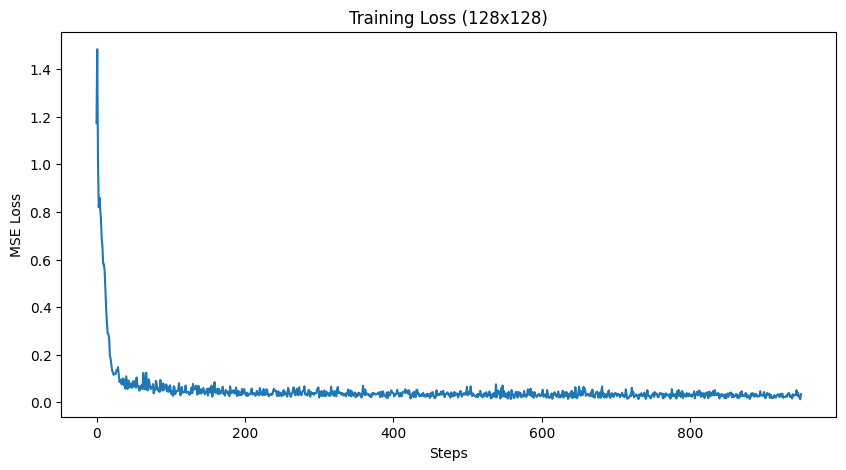

In [ ]:
# --- Global Diffusion Constants ---
BETA_START = 0.0001 # Starting noise level
BETA_END = 0.02 # End noise level
T_STEPS = 1000 # 1000 timesteps

def get_val(val_tensor, t, x_shape):
    """Helper to extract values from a tensor at specific time steps 't'. We need output shape like (B, 1, 1, 1)"""
    batch_t = t.long()
    out = val_tensor.gather(-1, batch_t).reshape(x_shape[0], *((1,) * (len(x_shape) - 1)))
    return out

# --- Training Function ---
def train_model(model, optimizer, train_loader, device, epochs=50, img_size=128):
    """
    Trains the Diffusion Model and saves the checkpoint.
    """
    print(f"Starting Training: {epochs} Epochs | Resolution: {img_size}x{img_size} | Device: {device}")
    
    # Pre-calculate Noise Schedule on the correct device
    betas = torch.linspace(BETA_START, BETA_END, T_STEPS).to(device) # Add noise variance at step t
    alphas = 1. - betas # Remain signals at step t
    alphas_cumprod = torch.cumprod(alphas, dim=0) # compute xt value

    model.train()
    losses = []

    # Training Loop
    for epoch in range(epochs):
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}") # Visualize progress for each epoch
        
        for batch_idx, batch in enumerate(pbar):
            # Load Data
            images = batch[0].to(device)
            
            # DEBUG: Sanity check on first batch of first epoch
            if epoch == 0 and batch_idx == 0:
                print(f"DEBUG: Image Range -> Min: {images.min().item():.2f}, Max: {images.max().item():.2f}")

            # Sample random time steps
            t = torch.randint(0, T_STEPS, (images.shape[0],), device=device)
            
            # Add Noise (Forward Diffusion Process)
            noise = torch.randn_like(images) # Gaussian noise N(0,1)
            sqrt_alpha_bar = get_val(torch.sqrt(alphas_cumprod), t, images.shape) # compute the each segments of the xt equation for each images's timesteps
            sqrt_one_minus_alpha_bar = get_val(torch.sqrt(1 - alphas_cumprod), t, images.shape)
            x_noisy = sqrt_alpha_bar * images + sqrt_one_minus_alpha_bar * noise
            
            # Predict Noise (Reverse Process)
            noise_pred = model(x_noisy, t)
            
            # Calculate Loss & Backprop
            loss = F.mse_loss(noise_pred, noise) # MSE (Mean Squared Error) between predicted noise and true noise
            
            optimizer.zero_grad() # Clear old gradients
            loss.backward() # Compute gradients of loss w.r.t all parameters
            optimizer.step() # Update weights using Adam
            
            losses.append(loss.item())
            pbar.set_description(f"Loss: {loss.item():.4f}") # Show the loss in progress

    print("Training Complete!")

    # Save Model
    save_path = f"ddpm_pneumonia_model_{img_size}x{img_size}.pth"
    torch.save(model.state_dict(), save_path)
    print(f"Model Saved to: {save_path}")

    # Plot Loss
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title(f"Training Loss ({img_size}x{img_size})")
    plt.xlabel("Steps")
    plt.ylabel("MSE Loss")
    plt.show()
    
    return alphas_cumprod, betas # Return these as we need them for sampling later!

# --- Execute Training ---
alphas_cumprod, betas = train_model(model, optimizer, train_loader, device, epochs=50, img_size=IMG_SIZE)

# 4. Load Pre-Trained Model (Skip Training)

**Use this cell if you have already trained the model.**
Instead of waiting until train the model again, this cell:
1.  Re-calculates the necessary diffusion schedules (`alphas`, `betas`).
2.  Initializes a fresh model.
3.  Loads your saved weights (`ddpm_pneumonia_128x128.pth`) from the disk.

If the file is not found, it will tell you to run the Training cell first.

In [ ]:
# --- Constants (Must match training!) ---
BETA_START = 0.0001
BETA_END = 0.02
T_STEPS = 1000

def load_trained_model(device, img_size=64):
    """
    Loads a pre-trained model and recalculates diffusion schedules.
    Returns: model, alphas_cumprod, betas
    """
    print(f"Attempting to load saved model for {img_size}x{img_size}...")
    
    # 1. Re-calculate the Noise Schedule (Fast)
    betas = torch.linspace(BETA_START, BETA_END, T_STEPS).to(device)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    
    # 2. Initialize Empty Model
    model = BetterUNet().to(device)
    
    # 3. Load Weights
    filename = f"ddpm_pneumonia_model_{img_size}x{img_size}.pth"
    
    if not os.path.exists(filename):
        print(f"Error: Model file '{filename}' not found!")
        print("You must run the TRAINING cell at least once to create this file.")
        return None, None, None
    
    # Load state dict
    try:
        model.load_state_dict(torch.load(filename, map_location=device))
        print(f"Successfully loaded '{filename}'!")
        print("You can now skip training and go straight to Image Generation.")
    except Exception as e:
        print(f"Error loading weights: {e}")
        print("The model architecture might have changed. Try retraining.")
        return None, None, None

    model.eval()
    return model, alphas_cumprod, betas

# --- EXECUTE LOADING ---
# Only run this if you want to SKIP training!
if 'alphas_cumprod' not in locals():
    # If variables don't exist yet (e.g., fresh restart), try loading
    model, alphas_cumprod, betas = load_trained_model(device, img_size=IMG_SIZE)
else:
    print("Model and schedules already loaded in memory.")

Model and schedules already loaded in memory.


# 5. Image Generation (Reverse Diffusion)

Now that the model has learned the **Score Function** (how to remove noise), we can perform the **Reverse Diffusion Process**.

**How it works:**
1.  We start with a tensor of **Pure Gaussian Noise** ($x_T$).
2.  We iterate backwards from $t = 1000$ down to $0$.
3.  At each step, we ask the model: *"How much noise is in this image?"*
4.  We subtract that noise (scaled by $\alpha$ and $\beta$) to get a slightly cleaner image ($x_{t-1}$).
5.  By step $0$, we should have a pristine, high-resolution X-Ray.

**Mathematical Formula (DDPM Algorithm 2):**
$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z$$

Generating 5 X-Rays from pure noise...


Denoising: 100%|██████████| 1000/1000 [00:19<00:00, 51.89it/s]



--- Final Generated Images ---


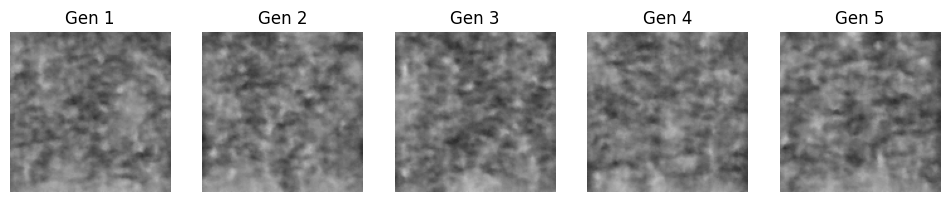


--- The Denoising Process (Noise -> Organ) ---


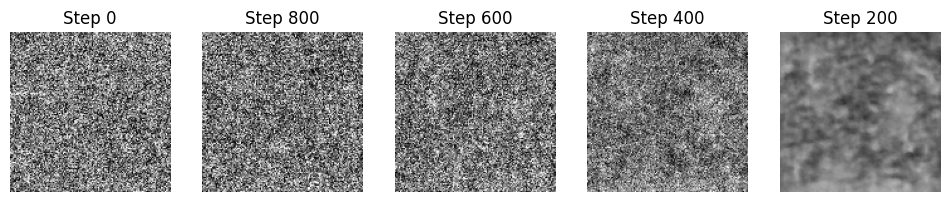

In [ ]:
# --- Modular Sampling Function ---

@torch.no_grad() # Update PyTorch to not to compute gradients as this is not trainign process

def generate_samples(model, device, alphas_cumprod, betas, n_samples=5, img_size=128, t_steps=1000):
    """
    Generates new images from pure noise using the trained model.
    """
    model.eval()
    print(f"Generating {n_samples} X-Rays from pure noise...")
    
    # Start with pure random noise (x_T)
    x = torch.randn(n_samples, 1, img_size, img_size).to(device)
    
    # Pre-calculate alphas for the specific formula
    # Move calculations to the correct device to ensure all tensors are on the same device (CPU or GPU)
    betas = betas.to(device)
    alphas_cumprod = alphas_cumprod.to(device)

    alphas = 1.0 - betas
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
    
    # Store snapshots to visualize the "healing" process
    snapshots = []
    
    # Iterate backwards from T to 0
    for i in tqdm(reversed(range(t_steps)), desc="Denoising", total=t_steps):
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        
        # Predict noise
        predicted_noise = model(x, t)
        
        # Get diffusion parameters for this step
        alpha = alphas[i]
        alpha_cumprod = alphas_cumprod[i]
        beta = betas[i]
        
        # Recover image (Standard DDPM Formula)
        # Inject Gaussian noise at each step except the last step
        if i > 0:
            noise = torch.randn_like(x)
        else:
            noise = torch.zeros_like(x) # No noise added at the final step
            
        # Remove predicted noise and add a tiny bit of Langevin noise (DDPM reverse update)
        # Calculate the mean
        mean = (1.0 / torch.sqrt(alpha)) * (x - ((1.0 - alpha) / torch.sqrt(1.0 - alpha_cumprod)) * predicted_noise)
        
        # Calculate the variance
        sigma = torch.sqrt(posterior_variance[i])

        # Combine mean and variance to get the healed image
        x = mean + sigma * noise # Add randomness (stochasticity) 
        
        # Stability Clamp (keep the sample stable and prevent out of range intensity spickes)
        x = torch.clamp(x, -1.0, 1.0)
        
        # Save snapshots at specific milestones (Start, 75%, 50%, 25%, End)
        if i % (t_steps // 5) == 0 or i == 0:
            snapshots.append(x[0].cpu().clone())

    # --- Visualization ---
    
    # Show Final Results
    plt.figure(figsize=(12, 4))
    print("\n--- Final Generated Images ---")
    for k in range(n_samples):
        plt.subplot(1, n_samples, k+1)
        img = x[k].cpu().squeeze().numpy()
        plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
        plt.axis('off')
        plt.title(f"Gen {k+1}")
    plt.show()

    # Show Denoising Process (Animation Strip)
    plt.figure(figsize=(12, 3))
    print("\n--- The Denoising Process (Noise -> Organ) ---")
    num_snaps = len(snapshots)
    for k, snap in enumerate(snapshots):
        plt.subplot(1, num_snaps, k+1)
        plt.imshow(snap.squeeze().numpy(), cmap='gray', vmin=-1, vmax=1)
        plt.axis('off')
        # Calculate step number based on index
        step_label = t_steps - (k * (t_steps // 5))
        if step_label == t_steps: step_label = 0 # Fix label for last one
        plt.title(f"Step {step_label}")
    plt.show()
    
    return x

# --- EXECUTE GENERATION ---
# Note: We use 'alphas_cumprod' and 'betas' returned from the training cell!
generated_xrays = generate_samples(model, device, alphas_cumprod, betas, n_samples=5, img_size=IMG_SIZE)

# 6. Anomaly Detection (The "Implicit Inpainting" Method)

This is the medical application of our project.

**The Logic:**
1.  We trained the model **only on Healthy lungs**. It literally does not know what Pneumonia looks like.
2.  We take a **Sick Lung (Pneumonia)** from the test set.
3.  We **corrupt** it by adding noise up to step $t=400$ (partially destroying the tissue details).
4.  We ask the model to **"heal" (denoise)** it back to step 0.
5.  Since the model forces everything to look "Healthy," it will **remove the Pneumonia** and replace it with healthy tissue.
6.  **Difference = Anomaly.** Subtracting the *Original (Sick)* from the *Healed (Healthy)* reveals the infection.

**Key Parameter:**
* `t_start` (e.g., 300-500): Controls how much we destroy the image.
    * **Low (200):** Only fine texture changes.
    * **High (600):** Major structural changes (risks hallucination).

Searching for Pneumonia case #7 in Test Set...
Loaded Pneumonia X-Ray (Test Index None)
Corrupting and Healing from step 400...


Healing: 100%|██████████| 400/400 [00:01<00:00, 219.86it/s]


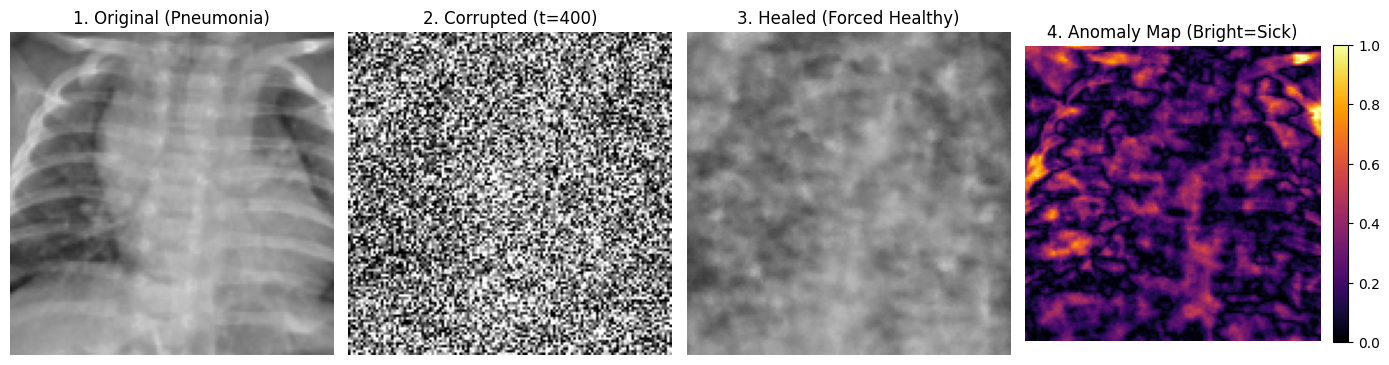

In [ ]:
# --- Anomaly Detection Function ---

@torch.no_grad()
def detect_anomalies(model, device, test_dataset, alphas_cumprod, betas, img_size=128, t_start=400, sample_index=0, diff_threshold=0.15):
    """
    Takes a Pneumonia image, adds noise, and lets the model 'heal' it to detect anomalies.
    """
    model.eval()
    print(f"Searching for Pneumonia case #{sample_index + 1} in Test Set...")
    
    # --- Ensure schedules are on the correct device ---
    betas = betas.to(device)
    alphas_cumprod = alphas_cumprod.to(device)

    # Precompute alphas and posterior variance (DDPM correct noise scale)
    alphas = 1.0 - betas
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
    posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

    # Find a Pneumonia Image (Class 1)
    target_img = None
    pneumonia_count = 0
    found_test_index = None
    
    # Loop through the test dataset to find the specific pneumonia case
    for idx in range(len(test_dataset)):
        img, label = test_dataset[idx]
        # MedMNIST labels are arrays like [1], so we use .item() to get the integer
        if label.item() == 1: 
            if pneumonia_count == sample_index:
                target_img = img.unsqueeze(0).to(device) # Add batch dim -> [1, 1, 128, 128]
                break
            pneumonia_count += 1
            
    if target_img is None:
        print("Could not find a Pneumonia image at that index.")
        return

    print(f"Loaded Pneumonia X-Ray (Test Index {found_test_index})")
    print(f"Corrupting and Healing from step {t_start}...")

    # Corrupt the image (Forward Diffusion to t_start)
    # Forward process: q(x_t | x_0) to jump directly to step t_start
    noise = torch.randn_like(target_img)
    alpha_bar_t = alphas_cumprod[t_start]  # already on device
    noisy_img = torch.sqrt(alpha_bar_t) * target_img + torch.sqrt(1.0 - alpha_bar_t) * noise

    # Reverse process: p(x_{t-1} | x_t) to heal the image back to step 0
    curr_img = noisy_img.clone()
    
    # Pre-calculate alphas for the reverse step
    alphas = 1.0 - betas

    for j in tqdm(reversed(range(0, t_start)), desc="Healing", total=t_start):
        t_tensor = torch.full((1,), j, device=device, dtype=torch.long)
        
        # Predict noise epsilon
        eps_pred = model(curr_img, t_tensor)
        
        # Params
        alpha_t = alphas[j]
        alpha_bar_t = alphas_cumprod[j]
        
        # DDPM mean (epsilon-parameteriation)
        mean = (1.0 / torch.sqrt(alpha_t)) * (curr_img - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred)
        
        # Recover image
        if j > 0:
            z = torch.randn_like(curr_img)
        else:
            z = torch.zeros_like(curr_img)
            
        # DDPM Sampling Step
        sigma = torch.sqrt(posterior_variance[j])
        curr_img = mean + sigma * z
        
        # Stability Clamp
        curr_img = torch.clamp(curr_img, -1.0, 1.0)
        
    # Calculate Difference (Anomaly Map)
    original = target_img.detach().cpu().squeeze().numpy()
    healed = curr_img.detach().cpu().squeeze().numpy()
    
    # Absolute difference tells us what changed
    diff = np.abs(original - healed)
    
    # Apply a small threshold to remove random background noise (only for visualization, not for actual detection)
    # This makes the infection spots pop out more clearly
    diff_vis = diff.copy()
    diff_vis[diff_vis<diff_threshold] = 0.0 
    
    # Visualization
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 4, 1)
    plt.title("1. Original (Pneumonia)")
    plt.imshow(original, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title(f"2. Corrupted (t={t_start})")
    plt.imshow(noisy_img.detach().cpu().squeeze().numpy(), cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title("3. Healed (Forced Healthy)")
    plt.imshow(healed, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("4. Anomaly Map (Bright=Sick)")
    plt.imshow(diff, cmap='inferno', vmin=0, vmax=1.0) 
    plt.colorbar(fraction=0.046, pad=0.04) 
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return original, healed, diff

# --- EXECUTE DETECTION ---
# We use the variables 'alphas_cumprod' and 'betas' from your training/loading cell
original, healed, diff = detect_anomalies(model, device, test_dataset, alphas_cumprod, betas, img_size=IMG_SIZE, t_start=400, sample_index=6, diff_threshold=0.15)

## Numerical Analysis (AUROC & Confusion Matrix)

In [ ]:
# === CACHING ANOMALY SCORES (MEAN + MULTIPLE TOP-K METHODS) ===

CACHE_PATH = "cached_scores_ddpm_t400_multi_topk.npz"

# Use the same t_start as before for consistency in the level of corruption (anomaly) we are testing against.
# Higher values mean stronger corruption before healing
t_start = 400

# TOP-K ratios for anomaly scoring
# Example: 0.01 means top 1% pixels with highest reconstruction error
TOPK_RATIOS = [0.005, 0.01, 0.02, 0.05]  # 0.5%, 1%, 2%, 5%

true_labels = []
scores_mean = []
scores_topk = {r: [] for r in TOPK_RATIOS}

model.eval()

betas_d = betas.to(device)
alphas_cumprod_d = alphas_cumprod.to(device)

# Precompute diffusion parameters used during reverse sampling
alphas = 1.0 - betas_d
alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod_d[:-1]])

# Posterior variance used in DDPM reverse step
posterior_variance = betas_d * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod_d)

print(f"Running the evaluation and saving scores to {CACHE_PATH}")

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Caching scores"):
        images = images.to(device)

        # --- Forward diffusion: add noise up to t_start ---
        # Instead of applying noise step-by-step, we directly
        # sample x_t using the closed-form formula q(x_t | x_0)
        noise = torch.randn_like(images)
        alpha_bar_t = alphas_cumprod_d[t_start]
        noisy = torch.sqrt(alpha_bar_t) * images + torch.sqrt(1.0 - alpha_bar_t) * noise

        # --- Reverse diffusion: reconstruct the image from x_t back to x_0 ---
        x = noisy.clone()
        for i in reversed(range(0, t_start)):
            
            t_step = torch.full((images.size(0),), i, device=device, dtype=torch.long)
            
            # Model predicts the noise ε
            eps_pred = model(x, t_step)

            alpha_t = alphas[i]
            alpha_bar = alphas_cumprod_d[i]

            # DDPM mean reconstruction formula
            mean = (1.0 / torch.sqrt(alpha_t)) * (
                x - ((1.0 - alpha_t) / torch.sqrt(1.0 - alpha_bar)) * eps_pred
            )

            z = torch.randn_like(x) if i > 0 else torch.zeros_like(x)
            sigma = torch.sqrt(posterior_variance[i])
            x = torch.clamp(mean + sigma * z, -1.0, 1.0)

        # —-- Compute reconstruction error (anomaly score) ---
        # The anomaly score is based on the difference between:
        # original image and reconstructed ("healed") image
        diff = torch.abs(images - x)
        mask = (images > -0.9).float()
        diff = diff * mask

        flat = diff.view(images.size(0), -1)

        # ---- Mean anomaly score (average pixel-wise error) ----
        masked_sum = flat.sum(dim=1)
        mask_count = mask.view(images.size(0), -1).sum(dim=1).clamp(min=1.0)
        
        mean_score = masked_sum / mask_count

         # Store labels
        labels_np = labels.squeeze().cpu().numpy().astype(int)
        true_labels.extend(labels_np.tolist())
        # Store mean scores
        scores_mean.extend(mean_score.cpu().numpy().tolist())

        # ---- TOP-K anomaly scores ----
        # Pneumonia usually appears as localized infection spots. 
        # Instead of averaging all pixels, we focus on the pixels with the highest reconstruction errors.
        for r in TOPK_RATIOS:
            k = max(1, int(r * flat.size(1)))
            topk_vals, _ = torch.topk(flat, k=k, dim=1)
            scores_topk[r].extend(topk_vals.mean(dim=1).cpu().numpy().tolist())

# Save all arrays into one file
save_dict = {
    "y": np.array(true_labels, dtype=np.int64),
    "mean": np.array(scores_mean, dtype=np.float32),
    "t_start": np.array([t_start]),
    "topk_ratios": np.array(TOPK_RATIOS, dtype=np.float32),
}
for r in TOPK_RATIOS:
    key = f"topk_{str(r).replace('.','p')}"   # e.g., topk_0p01
    save_dict[key] = np.array(scores_topk[r], dtype=np.float32)

np.savez(CACHE_PATH, **save_dict)
print("Saved multi-topk cached scores ✅")

Running the evaluation saving multiple TOP-K ratios to cached_scores_ddpm_t400_multi_topk.npz


Caching scores: 100%|██████████| 10/10 [15:13<00:00, 91.32s/it]

Saved multi-topk cached scores ✅


Keys in cache: ['mean', 't_start', 'topk_0p005', 'topk_0p01', 'topk_0p02', 'topk_0p05', 'topk_ratios', 'y']

Included TOP-K keys:
  topk_0p005 -> TOP-0.50%
  topk_0p01 -> TOP-1.00%
  topk_0p02 -> TOP-2.00%
  topk_0p05 -> TOP-5.00%

Skipped keys (not per-image score arrays):
  topk_ratios: shape=(4,)

AUROC results:
  MEAN       AUROC = 0.7474
  TOP-0.50%  AUROC = 0.8442
  TOP-1.00%  AUROC = 0.8495
  TOP-2.00%  AUROC = 0.8509
  TOP-5.00%  AUROC = 0.8443

Best method: TOP-2.00% (AUROC = 0.8509)


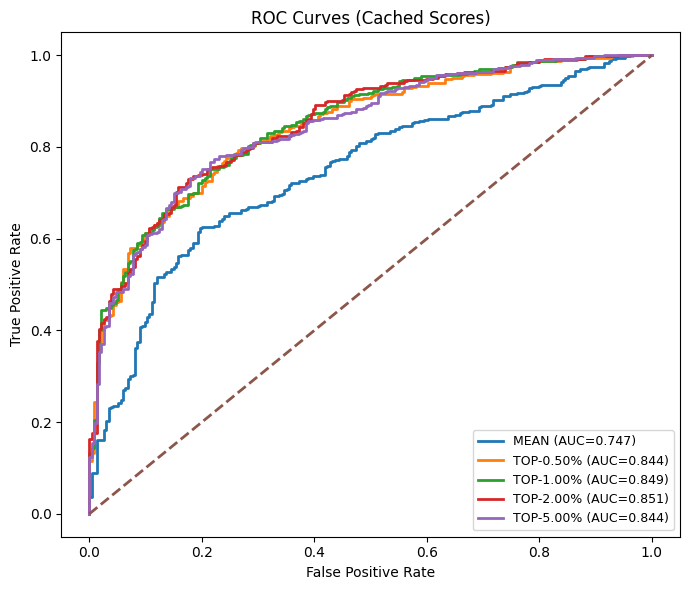

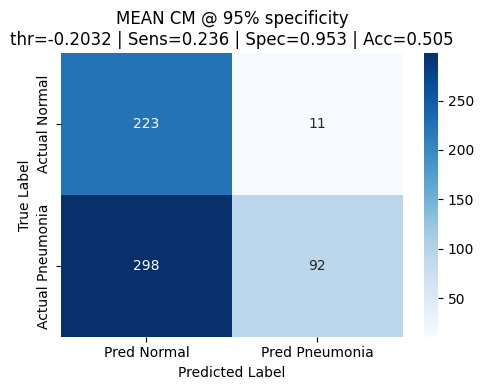

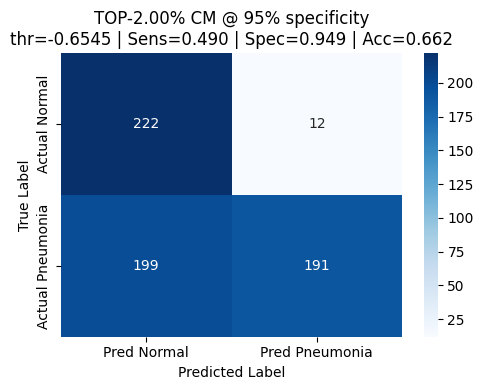

In [ ]:
# === LOADING CACHED SCORES + FINAL EVALUATION REPORT ===

CACHE_PATH = "cached_scores_ddpm_t400_multi_topk.npz"

# Choose specificity target for threshold selection (95% = strict on false positives)
TARGET_SPEC = 0.95

# Load cached arrays
data = np.load(CACHE_PATH, allow_pickle=True)
print("Keys in cache:", sorted(data.files))

# True labels for each test image (0=normal, 1=pneumonia)
y = data["y"].astype(int)
n = len(y) # number of test samples

# Score direction
# AUROC assumes: higher score = more likely positive class (pneumonia)
# But sometimes the scoring can be reversed (normal has higher score).
# If that happens, we flip scores by multiplying by -1.
def fix_direction(y, s):
    # Ensure higher score => more pneumonia
    if s[y == 1].mean() < s[y == 0].mean():
        return -s
    return s

# Choose threshold based on target specificity
# We compute ROC curve thresholds, then select the threshold that gives
# specificity closest to TARGET_SPEC.
def threshold_at_specificity(y, scores, target_spec=0.95):
    fpr, tpr, thr = roc_curve(y, scores)
    
    # Filter out any infinite thresholds (can happen if there are duplicate scores)
    finite = np.isfinite(thr)
    fpr_f, thr_f = fpr[finite], thr[finite]
    spec_f = 1 - fpr_f
    
    # Pick threshold whose specificity is closest to desired target
    idx = np.argmin(np.abs(spec_f - target_spec))
    return thr_f[idx]

# -- Confusion matrix + metrics --
def cm_and_metrics(y, scores, thr):
    pred = (scores > thr).astype(int)
    cm = confusion_matrix(y, pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp + 1e-12)
    sens = tp / (tp + fn + 1e-12)
    acc  = (tp + tn) / (tp + tn + fp + fn + 1e-12)
    return cm, sens, spec, acc

# --- Collect methods safely ----
methods = {}

# 1 - MEAN
mean_scores = data["mean"].astype(np.float32)

# Sanity check
if len(mean_scores) != n:
    raise ValueError(f"'mean' length {len(mean_scores)} != y length {n}")
methods["MEAN"] = fix_direction(y, mean_scores)

# 2 - TOP-K score arrays
# Filter only keys starting with "topk_" and length == n (per-image scores)
topk_keys = sorted([k for k in data.files if k.startswith("topk_")])

kept = [] # topk arrays used in evaluation
skipped = [] # keys that are not per-image scores (metadata arrays etc.)

for k in topk_keys:
    arr = data[k]

    # Skip non 1D arrays OR arrays that do not match dataset length
    if arr.ndim != 1 or len(arr) != n:
        skipped.append((k, arr.shape))
        continue

    # Create readable label from key name (e.g., topk_0p01 -> TOP-1.00%)
    raw = k.replace("topk_", "").replace("p", ".")
    try:
        ratio = float(raw)
        label = f"TOP-{ratio*100:.2f}%"
    except:
        label = k

    methods[label] = fix_direction(y, arr.astype(np.float32))
    kept.append((k, label))

print("\nIncluded TOP-K keys:")
for k, label in kept:
    print(f"  {k} -> {label}")

if skipped:
    print("\nSkipped keys (not per-image score arrays):")
    for k, shape in skipped:
        print(f"  {k}: shape={shape}")

# --- AUROC table ---
print("\nAUROC results:")
auroc_table = []
for name, scores in methods.items():
    au = roc_auc_score(y, scores)
    auroc_table.append((name, au))
    print(f"  {name:<10} AUROC = {au:.4f}")

# Identify the best method (highest AUROC)
best_name, best_auc = max(auroc_table, key=lambda x: x[1])
print(f"\nBest method: {best_name} (AUROC = {best_auc:.4f})")

# --- ROC plot ---
plt.figure(figsize=(7, 6))
for name, scores in methods.items():
    fpr, tpr, _ = roc_curve(y, scores)
    au = roc_auc_score(y, scores)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={au:.3f})")

# diagonal baseline = random classifier
plt.plot([0, 1], [0, 1], linestyle="--", lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Cached Scores)")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

# --- Confusion matrices: MEAN + BEST ---
def plot_cm(name):
    scores = methods[name]
    
    # Choose threshold so that specificity is ~TARGET_SPEC
    thr = threshold_at_specificity(y, scores, target_spec=TARGET_SPEC)

     # Compute confusion matrix + metrics
    cm, sens, spec, acc = cm_and_metrics(y, scores, thr)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Pred Normal", "Pred Pneumonia"],
        yticklabels=["Actual Normal", "Actual Pneumonia"]
    )
    plt.title(
        f"{name} CM @ {TARGET_SPEC*100:.0f}% specificity\n"
        f"thr={thr:.4f} | Sens={sens:.3f} | Spec={spec:.3f} | Acc={acc:.3f}"
    )
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

plot_cm("MEAN")
if best_name != "MEAN":
    plot_cm(best_name)